# (03) Kyoto16, gaussian-sigmoid: z-256, (16, 32.0)

project = ```P-VIB```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Reproduce

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Larger LR

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 256
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 32.0

cfg_tr['epochs']= 1000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |   66.6 K   |
|     ———     |    ———     |
|    layer    |   66.6 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[256]_u-(7,2),du-(7,3)_<grad|lin>
b200-ep1000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_04,09:55)

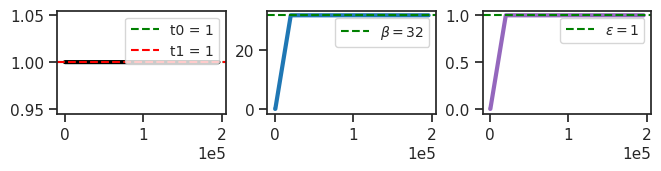

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

196000

In [6]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=256, temperature=1, beta_inner=1, eps=1)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [8]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: 214.278: 100%|████| 1000/1000 [2:17:13<00:00,  8.23s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0504], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0045], device='cuda:1', grad_fn=<ExpBackward0>))

100%|███████████████████████████████████| 2/2 [00:27<00:00, 13.57s/it]


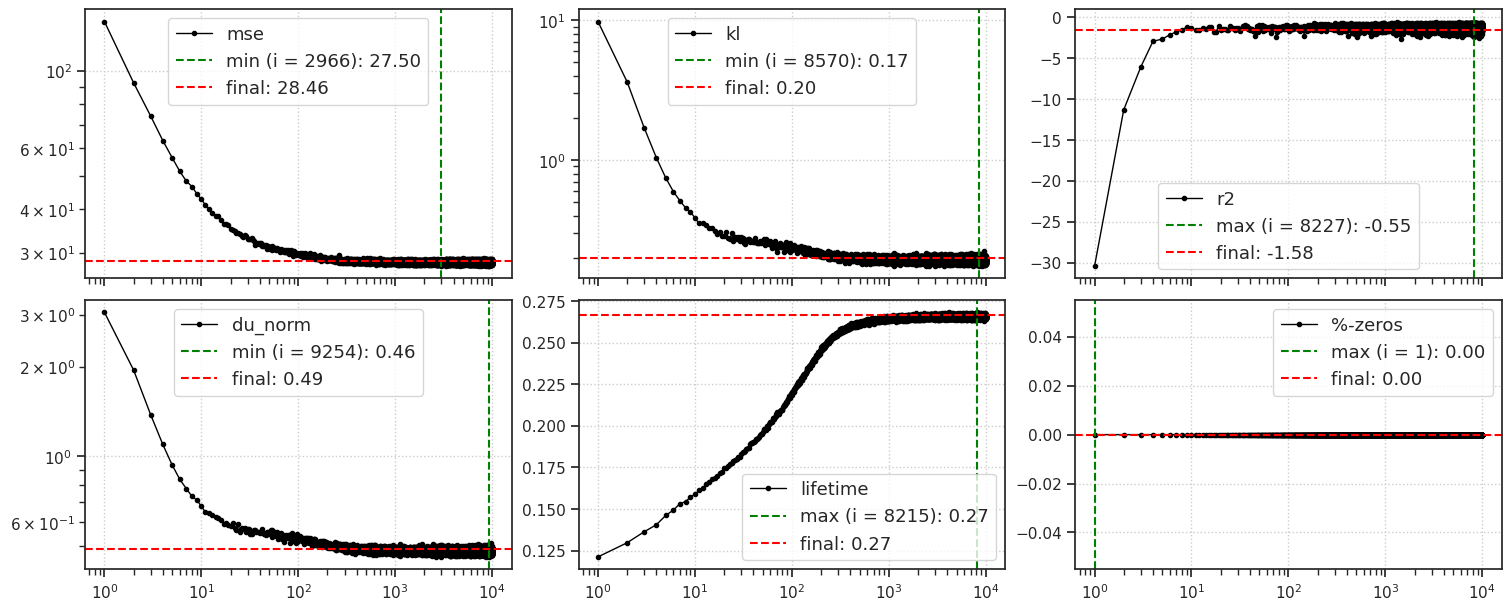

CPU times: user 32.8 s, sys: 1.42 s, total: 34.2 s
Wall time: 34.2 s


In [10]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

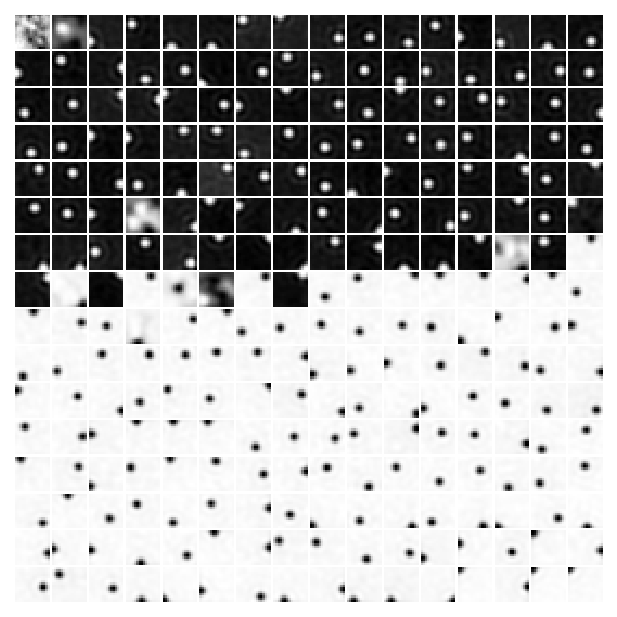

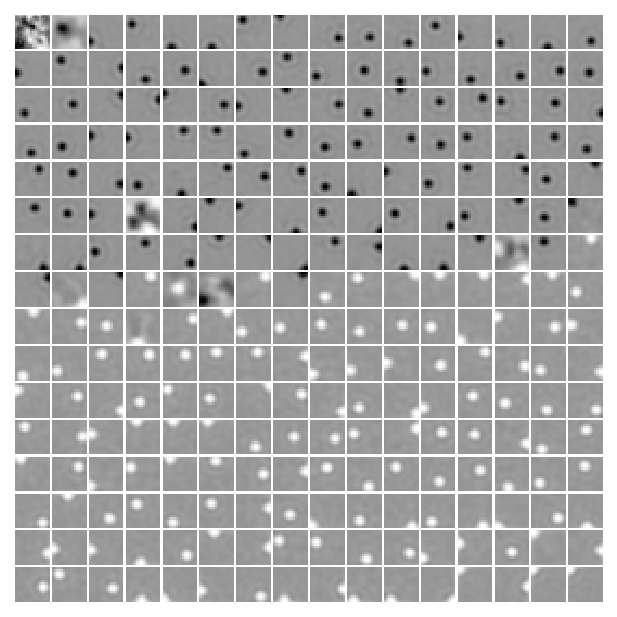

In [14]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

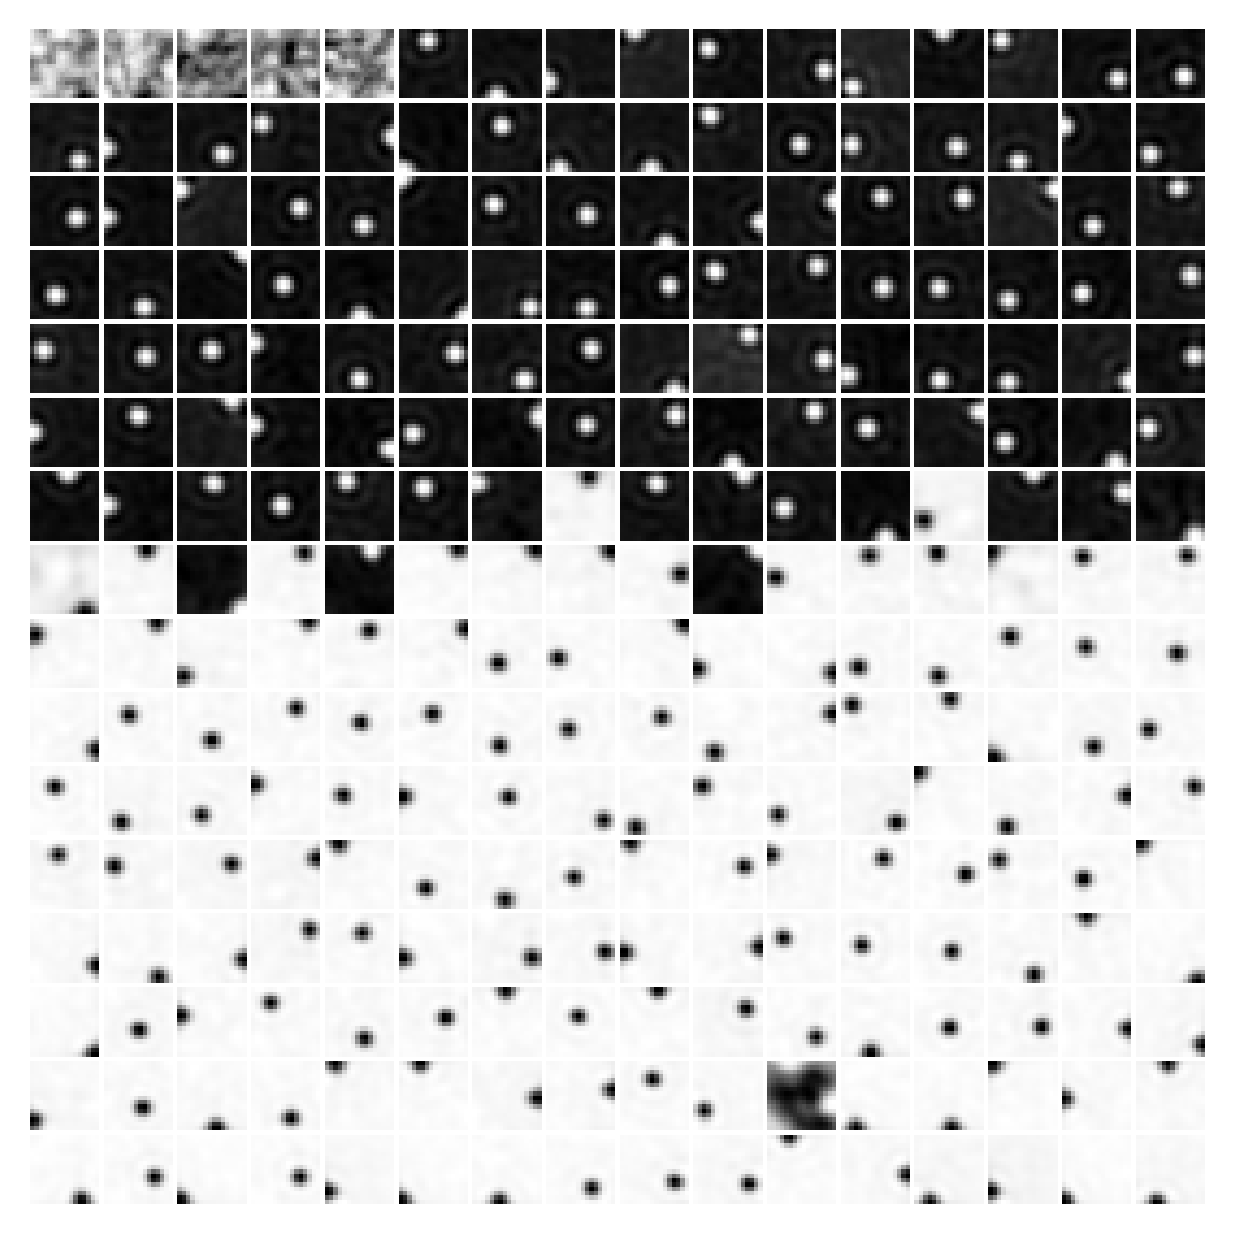

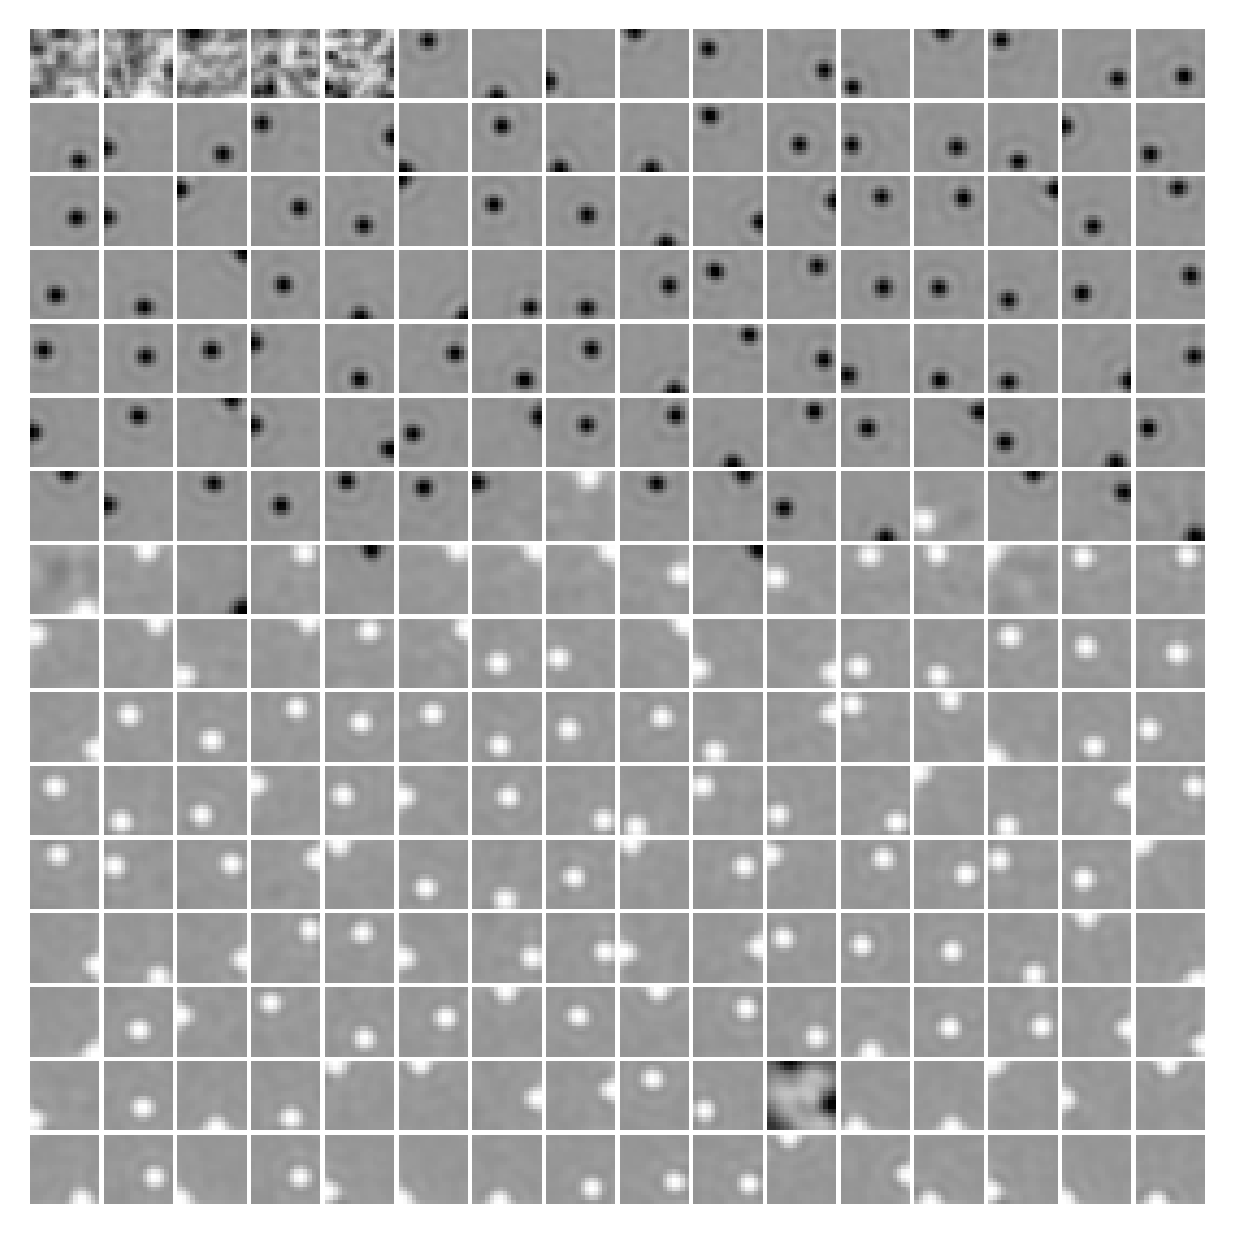

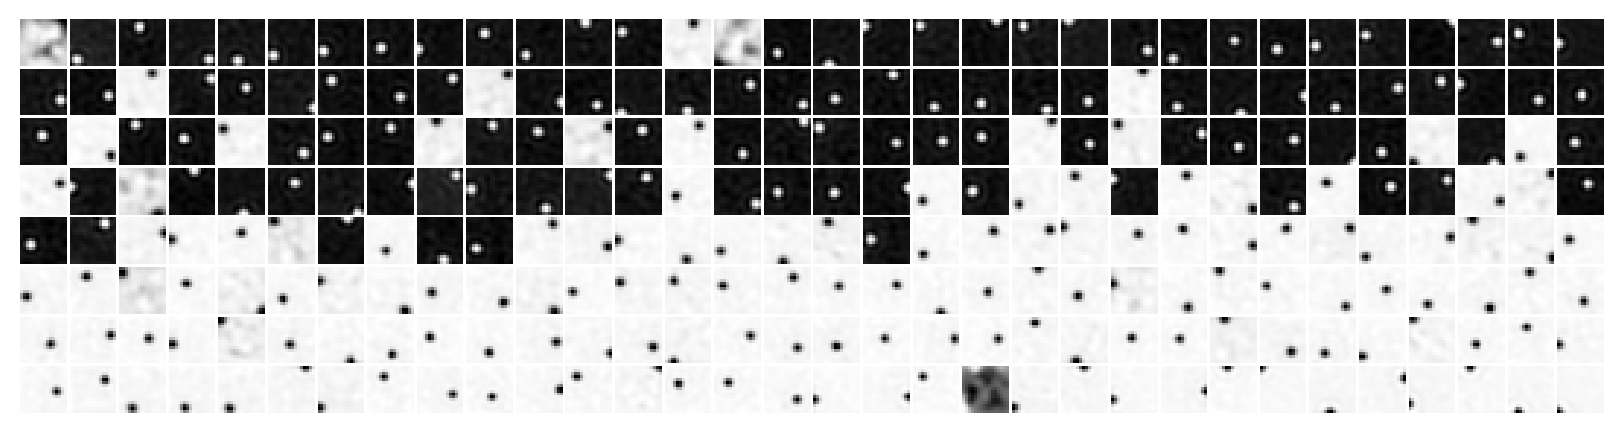

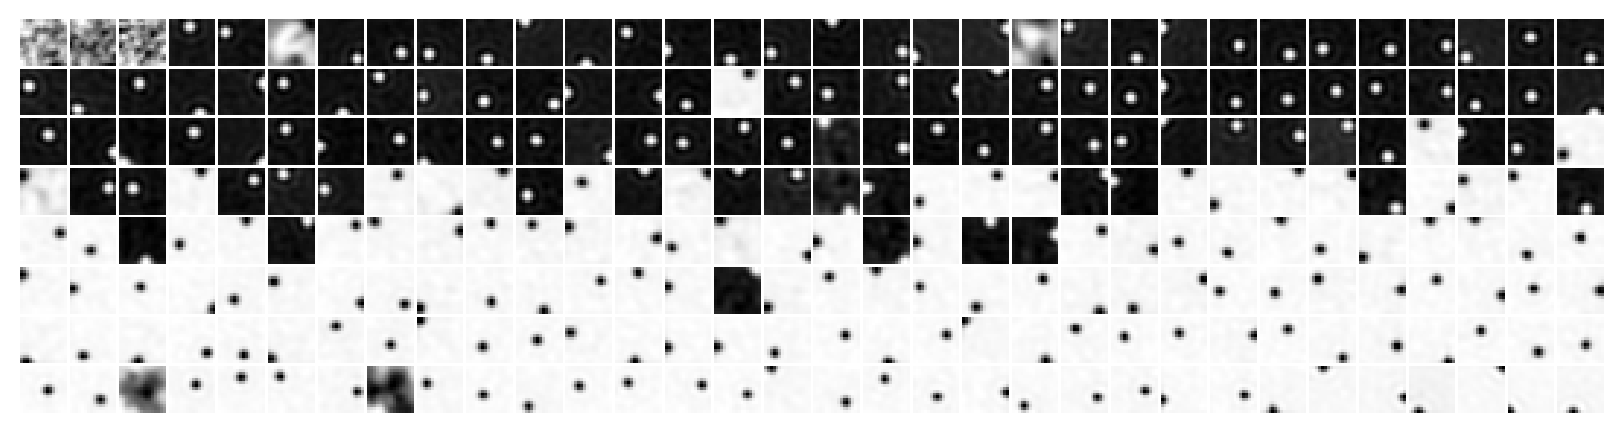

In [13]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([256, 16, 16])

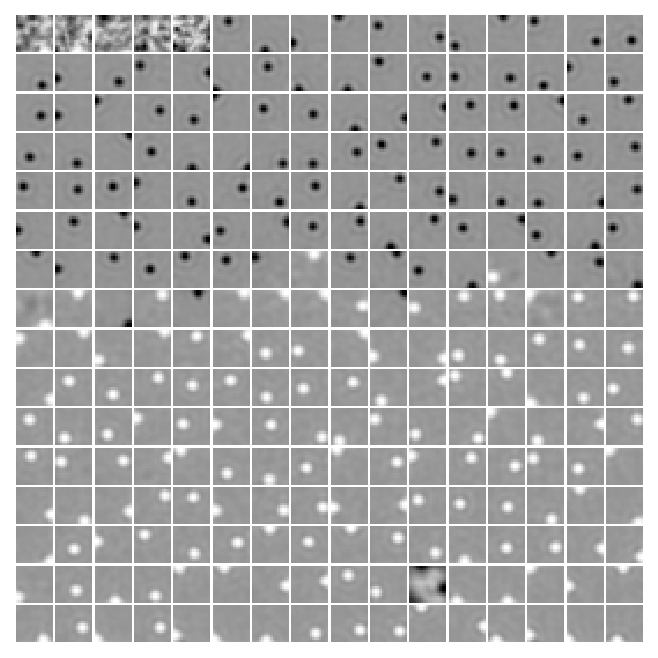

In [15]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
    nrows=16,
);

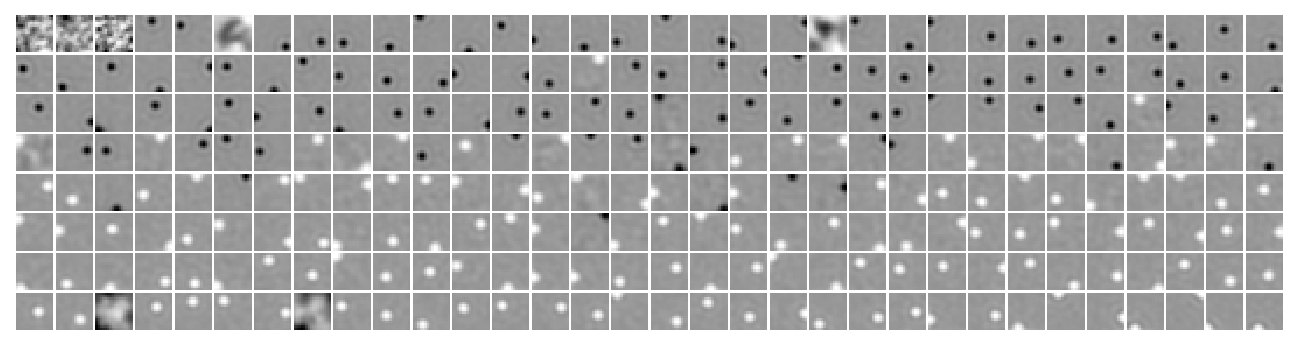

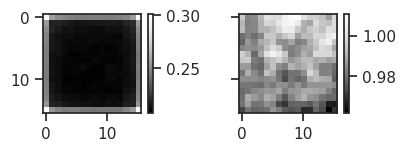

In [16]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.90s/it]


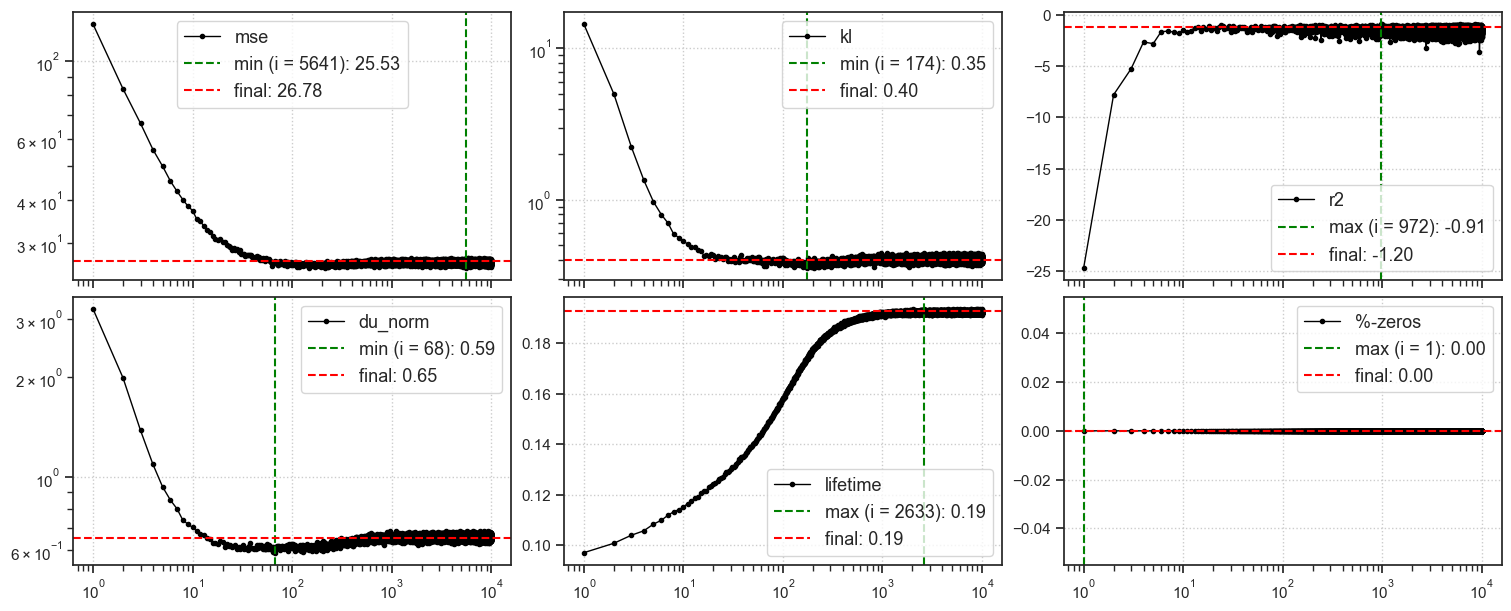

CPU times: user 44.7 s, sys: 4.69 s, total: 49.4 s
Wall time: 49.4 s


In [41]:
output = tr.xtract_ftr('vld', 1000, 100)
print(list(output))

100%|█████████████████████████████████| 50/50 [01:02<00:00,  1.26s/it]


['r2', 'mse', 'state', 'samples', 'times']

In [51]:
u = output['state'].copy()
z = output['samples'].copy()

u.shape, z.shape

((9801, 11, 256), (9801, 11, 256))

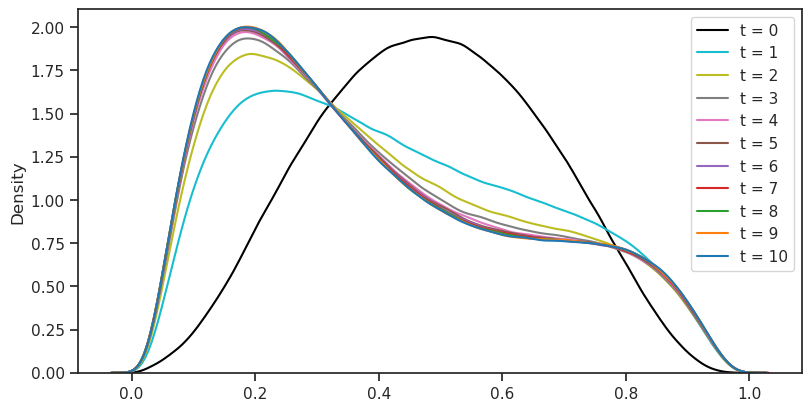

In [50]:
fig, ax = create_figure(1, 1, (8, 4))
for i in range(z.shape[1]):
    sns.kdeplot(z[:, i, :].ravel(), color=f'C{10-i}' if i > 0 else 'k', label=f't = {i}')
add_legend(ax)
plt.show()

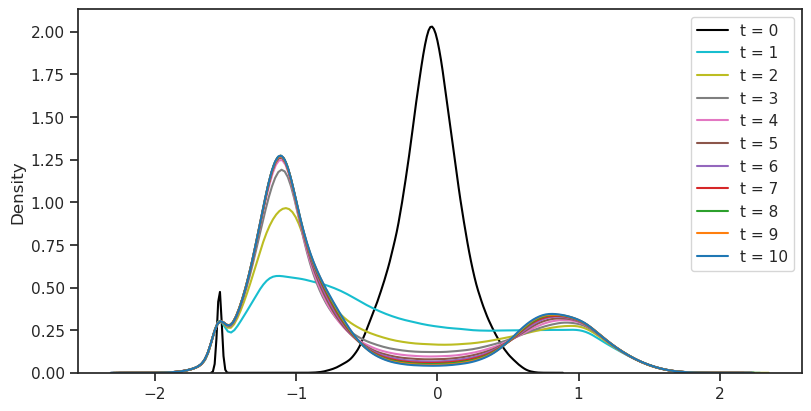

In [54]:
fig, ax = create_figure(1, 1, (8, 4))
for i in range(u.shape[1]):
    sns.kdeplot(u[:, i, :].ravel(), color=f'C{10-i}' if i > 0 else 'k', label=f't = {i}')
add_legend(ax)
plt.show()

In [36]:
print(sp_stats.pearsonr(u0, z[-1]))
print(sp_stats.spearmanr(u0, z[-1]))

PearsonRResult(statistic=0.9789997445138829, pvalue=1.902697869449812e-177)

SignificanceResult(statistic=0.567335917830167, pvalue=3.2998444172361067e-23)

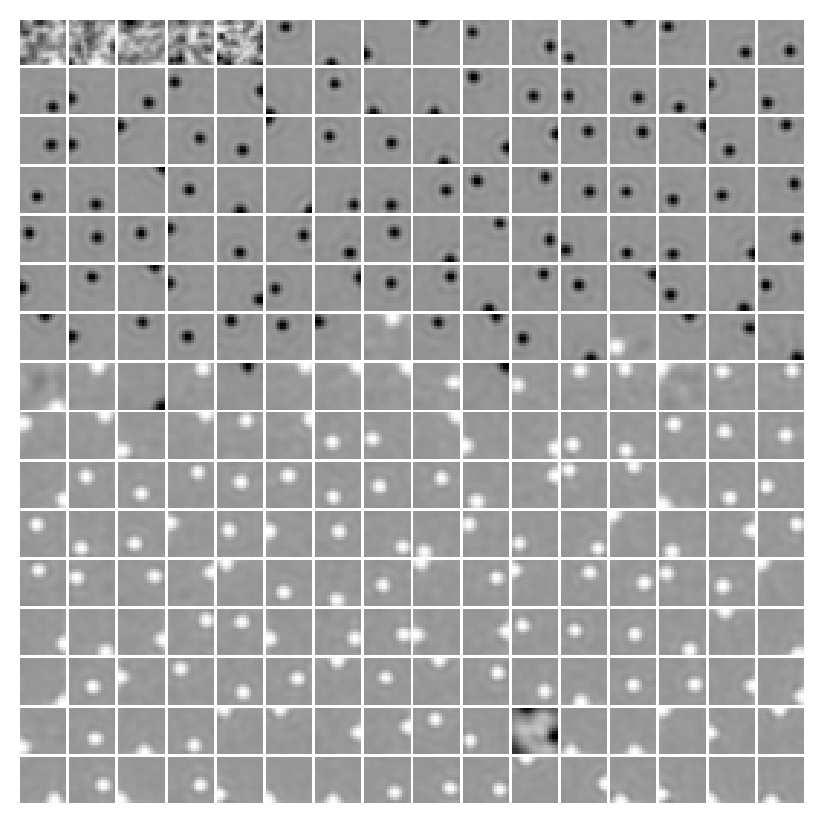

In [38]:
tr.model.show(order=np.argsort(u0), method='abs-max');